<a href="https://colab.research.google.com/github/Mohamad-Selawy/Data-Analysis/blob/main/Python/Visualization/Part_2_Visualization_with_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Visualization with Seaborn: Beyond Matplotlib

---

## Setup and Data Loading

First, let's import the necessary libraries and load our dataset. We'll be using a Sales Forecasting dataset throughout this notebook to ground our learning in a real-world business context.

In [30]:
# Import necessary libraries
import pandas as pd # For data manipulation and analysis
import matplotlib.pyplot as plt # For basic plotting and customization (Seaborn is built on it)
import seaborn as sns # For advanced statistical data visualization
import kagglehub # For downloading datasets from Kaggle

### Download and Load the Dataset

We'll use the 'sales-forecasting' dataset from KaggleHub. This dataset contains sales records that we can analyze to understand trends, patterns, and relationships.

In [31]:
# Download the dataset from KaggleHub
path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")

data_file_path = f"{path}/train.csv" # Adjust filename if different

# Load the dataset into a Pandas DataFrame
df = pd.read_csv(data_file_path)

Using Colab cache for faster access to the 'sales-forecasting' dataset.


### Initial Data Exploration

Let's get a first look at our data to understand its structure, types, and summary statistics. This is crucial before we start visualizing.

In [32]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Data Preprocessing: Date Columns

Before diving into visualizations, it's good practice to ensure our data types are correct. We noticed that 'Order Date' and 'Ship Date' are currently `object` types. For any time-based analysis or plotting, these need to be converted to `datetime` objects.

In [33]:
df = df.dropna()
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = df['Order Date'].astype('datetime64[ns]')
df['Ship Date'] = df['Ship Date'].astype('datetime64[ns]')
df['Profit'] = df['Sales'] * 0.2
# Verify the conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

## — Essential Seaborn Charts

In this section, we will explore some of the most commonly used and powerful Seaborn charts. For each chart, we will cover its purpose, when to use it (and when not to), a business example, fully commented Python code, important parameters.

### 1. Scatter Plot (`sns.scatterplot()`)

*   **Purpose:** To visualize the relationship between two continuous variables.
*   **When to Use It:**
    *   To identify correlations or trends between two quantitative variables.
    *   To detect outliers or clusters in the data.
    *   When you have a moderate number of data points. For very large datasets, alternatives like hexbin plots or 2D histograms might be more suitable due to overplotting.
*   **When Not to Use It:**
    *   For visualizing categorical data or a single variable's distribution.
    *   When dealing with time series, a line plot is usually more appropriate.

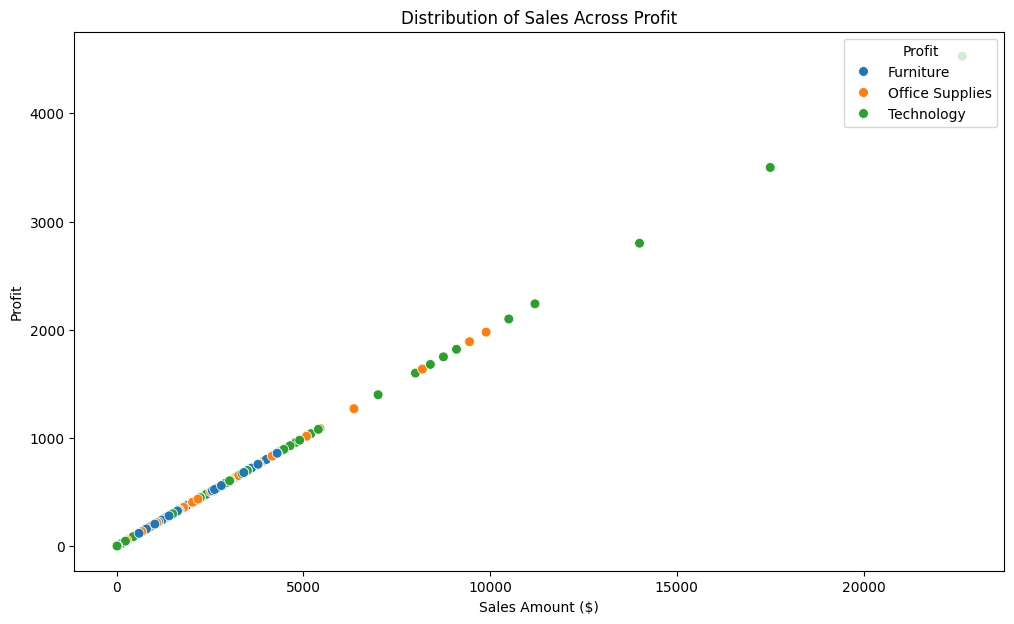

In [34]:
# Business Example: Sales distribution across Categories
# Let's visualize the distribution of sales values for each product category.
# While not a direct correlation, it helps understand the range of sales within each category.

plt.figure(figsize=(12, 7))
# Create a scatter plot using Seaborn
# x='Sales': Specifies the column for the x-axis (continuous variable)
# y='Category': Specifies the column for the y-axis (categorical variable for comparison)
# data=df: The DataFrame to draw the plot from
# hue='Category': Colors the points based on the 'Category' column, helping differentiate categories
# s=50: Sets the size of the points
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Category',  s=50)

plt.title('Distribution of Sales Across Profit')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Profit')
plt.legend(title='Profit', loc='upper right') # Place legend outside the plot
plt.show()

### 2. Line Plot (`sns.lineplot()`)

*   **Purpose:** To visualize the trend of one or more variables over time or an ordered category.
*   **When to Use It:**
    *   When one of your variables represents a sequence, such as time (dates, months, years) or an ordered category.
    *   To show how a variable changes or evolves over a continuous interval.
    *   To compare trends between different groups over time.
*   **When Not to Use It:**
    *   For comparing discrete, unordered categories.
    *   To show relationships between two continuous variables where order isn't a factor (use a scatter plot).
*   **Business Example:** Analyzing `Sales` trends over time. We will aggregate sales by `Order Date` to see how total sales change daily, weekly, or monthly.

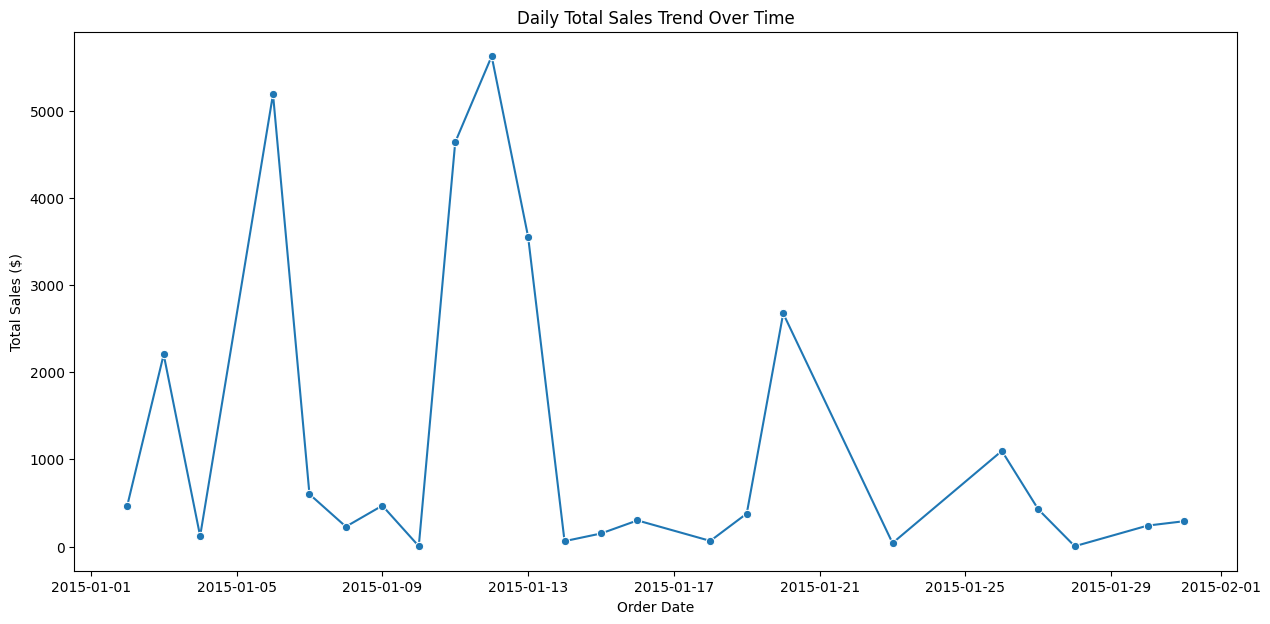

In [67]:
# Business Example: Daily Sales Trend
# First, we need to aggregate sales data by 'Order Date'.
# We'll calculate the sum of sales for each day.
df_2015 = df[df['Order Date'].between('2015-01-01','2015-01-31')]
daily_sales = df_2015.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(15, 7))
# Create a line plot using Seaborn
# x='Order Date': Specifies the time variable for the x-axis
# y='Sales': Specifies the continuous variable for the y-axis
# data=daily_sales: The aggregated DataFrame
# marker='o': Adds markers to each data point (optional, but good for discrete points)
sns.lineplot(x='Order Date', y='Sales', data=daily_sales, marker='o')

plt.title('Daily Total Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales ($)')
plt.show()

### 3. Bar Plot (`sns.barplot()`)

*   **Purpose:** To display and compare the numerical values of different categories. It shows the central tendency (mean by default) and optionally the confidence interval for a numerical variable across different categories.
*   **When to Use It:**
    *   When you want to compare a quantitative value (e.g., total sales, average profit) across different discrete categories (e.g., product categories, regions, customer segments).
    *   To visualize grouped data where each bar represents a category and its height represents a summary statistic (mean, sum, etc.) of a numerical variable.
*   **When Not to Use It:**
    *   For visualizing distributions of a single continuous variable (use a histogram or KDE plot).
    *   For showing relationships between two continuous variables (use a scatter plot).
    *   When the number of categories is very large, making the plot cluttered.

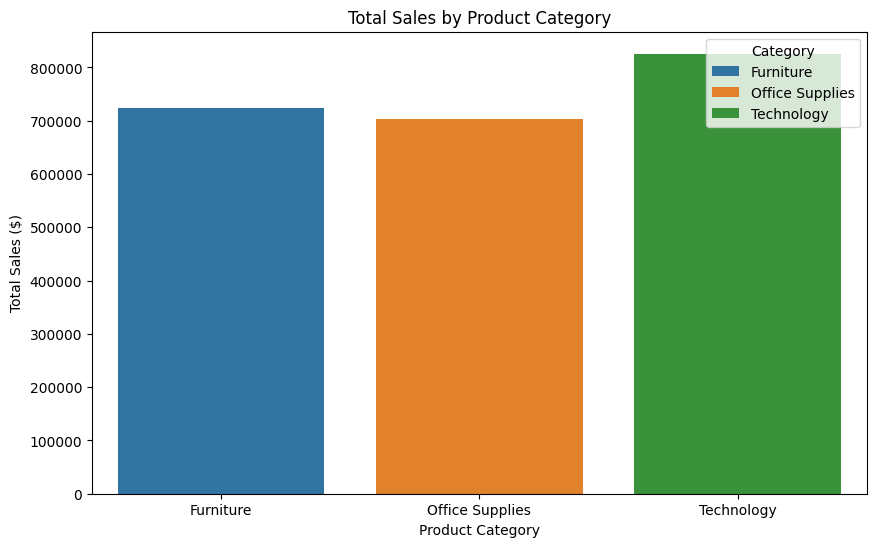

In [56]:
from ipywidgets import Label
# Business Example: Average Sales by Product Category
# We want to see which product categories have the highest average sales per transaction.

plt.figure(figsize=(10, 6))
# Create a bar plot using Seaborn
# x='Category': The categorical variable for the x-axis
# y='Sales': The numerical variable for which to calculate the average and display on the y-axis
# data=df: The DataFrame to draw the plot from
# estimator=sum: aggregation function
# error bar : is a line on a chart that extends above and below a bar to show the variability or spread of the underlying data.
sns.barplot(x='Category', y='Sales', data=df, hue='Category', legend=True, estimator='sum',errorbar=None)

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.show()

### 4. Histogram (`sns.histplot()`)

*   **Purpose:** To visualize the distribution of a single numerical variable. It shows the frequency of data points within specified bins.
*   **When to Use It:**
    *   To understand the shape, central tendency, and spread of a continuous dataset.
    *   To identify peaks (modes) in the data, indicating common values or subgroups.
    *   To detect outliers or unusual data points.
*   **When Not to Use It:**
    *   To show relationships between two variables (use scatter plots, line plots, etc.).

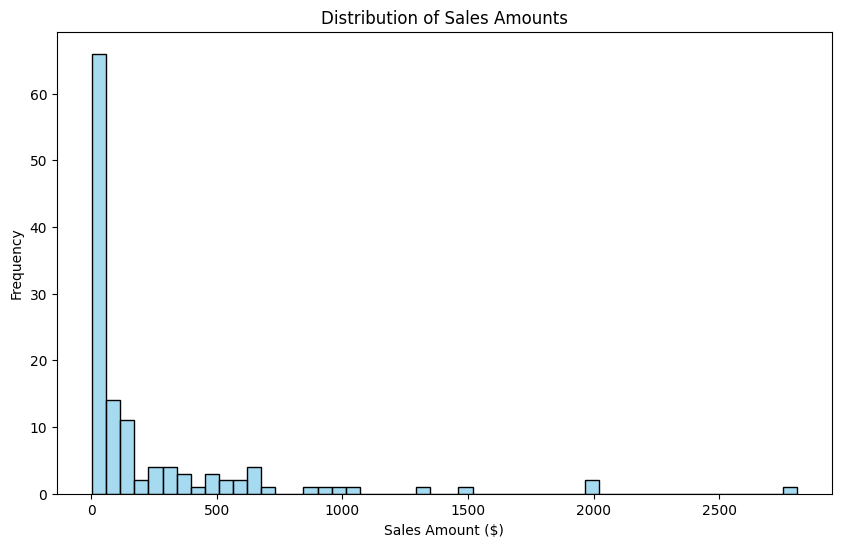

In [68]:
# Business Example: Distribution of Sales
# Let's revisit the sales distribution using a histogram to understand its shape.

df_2015 = df[df['Order Date'].between('2015-01-01','2015-01-31')]

plt.figure(figsize=(10, 6))
# Create a histogram using Seaborn
# x='Sales': The numerical column whose distribution we want to visualize
# data=df: The DataFrame to draw the plot from
# bins=50: Specifies the number of bins. More bins show more detail, fewer bins show a smoother overview.
# color='skyblue': Sets the color of the bars.
sns.histplot(x='Sales', data=df_2015, bins=50, color='skyblue')

plt.title('Distribution of Sales Amounts')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')
plt.show()

### 5. Box Plot (`sns.boxplot()`)

*   **Purpose:** To display the distribution of a numerical variable and compare it across different categories.
*   **When to Use It:**
    *   To quickly visualize the five-number summary (minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum) of a dataset.
    *   To identify outliers in the data (points beyond the "whiskers").
    *   To compare the spread and central tendency of a numerical variable across different groups.
*   **When Not to Use It:**
    *   When you need to see the exact shape of the distribution (use a histogram).
    *   For showing relationships between two continuous variables.

#### **Dealing with Outliers:** Removing Outliers by Region

While box plots effectively *show* outliers, sometimes it's useful to analyze or visualize the data after removing these extreme values. We'll use the Interquartile Range (IQR) method to filter out outliers for 'Sales' within each 'Region'.

In [38]:
# Calculate Q1, Q3, and IQR for 'Sales' globally (not per region)
Q1 = df['Sales'].describe()['25%']
Q3 = df['Sales'].describe()['75%']
IQR = Q3 - Q1

# Define outlier bounds: values outside of [Q1 - 1.5*IQR, Q3 + 1.5*IQR] are considered outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers to create a new DataFrame
df_no_outliers = df[
    (df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)
].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after global outlier removal: {df_no_outliers.shape}")

Original DataFrame shape: (9789, 19)
DataFrame shape after global outlier removal: (8648, 19)


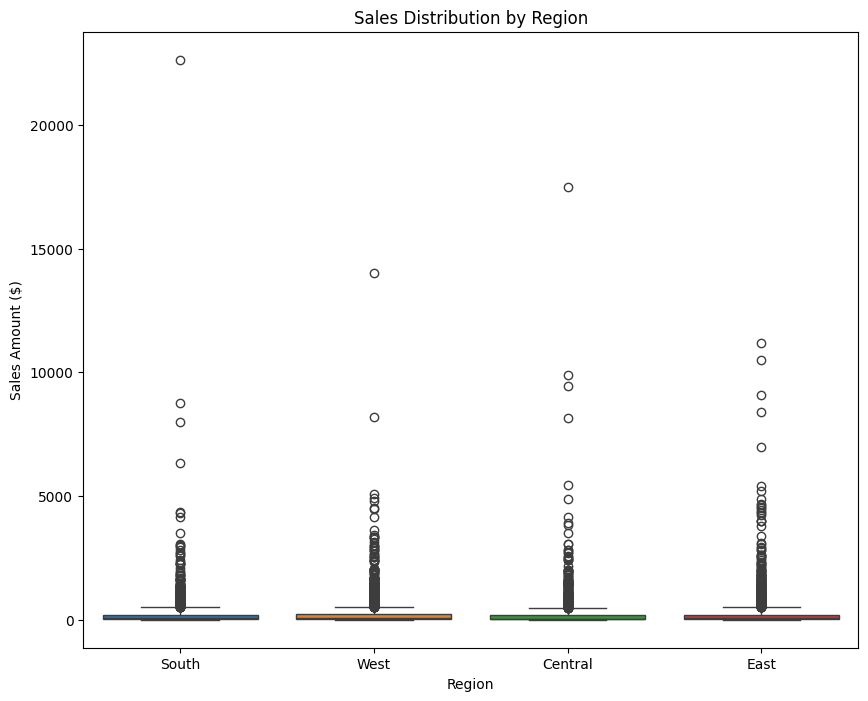

In [39]:
# Business Example: Sales Distribution by Region
# Let's compare how sales vary across different geographical regions.

plt.figure(figsize=(10, 8))
# Create a box plot using Seaborn
# x='Region': The categorical variable for the x-axis
# y='Sales': The numerical variable for the y-axis, whose distribution will be shown for each region
# data=df: The DataFrame to draw the plot from
sns.boxplot(x='Region', y='Sales', data=df, hue='Region')

plt.title('Sales Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales Amount ($)')
plt.show()

## Practice Exercises

To solidify your understanding of Seaborn and data visualization, complete the following exercises using the `df` (sales forecasting) DataFrame. Remember to choose the most appropriate chart type, include proper titles and labels, and write a brief interpretation and business insight for each.

1.  **Sales Distribution by State:** Create a visualization to show the distribution of `Sales` for the top 10 states by total sales. What does this tell you about sales performance geographically?
    *   *Hint: Aggregate sales by State first, then filter, then use a box.*

2.  **Order Frequency by Customer Segment:** Visualize how many orders come from each `Segment` (Consumer, Corporate, Home Office). Which segment places the most orders?

3.  **Average Sales per Segment over Time:** Plot the average monthly sales for each `Segment` over the entire dataset. Do any segments show distinct trends or seasonality?
    *   *Hint: Aggregate average sales by 'Order YearMonth' and 'Segment', then use `sns.lineplot` with `hue`.*